# Template progetto d'esame

Questo notebook è una struttura generale da usare come base per il progetto.

Compilate ogni sezione con:
- testo descrittivo
- codice
- grafici
- commenti ai risultati

---

## Titolo del progetto
**Classificazione di tumori benigni e maligni**

## Studente / Gruppo
**Cardillo Antonino - Ragazzini Manuel**


# 1. Introduzione del problema

In questa sezione descrivere:
- il problema che si vuole affrontare

    Addestrare un modello per l'identificazione quanto più reale di tumori maligni.
    
- il tipo di task (classificazione, clustering, forecasting, regressione, outlier detection, ecc.)

- l'obiettivo del progetto

    Vogliamo dimostrare numericamente che le cellule maligne sono davvero più grandi e deformi di quelle benigne e quindi diagnosticare quanto più preciso entrambi i casi.

- l'interesse pratico o applicativo del problema

    Avere una diagnosi quanto più veritiera ci permetterà di evitare principalmente i falsi negativi che è la cosa più importante, evitando di mandare a casa una paziente ammalata, cosa meno preoccupante i falsi positivi. 


# 2. Descrizione del dataset

In questa sezione inserire:
- origine del dataset -

    https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
- descrizione delle variabili

    Le variabili rappresentano la trasformazione delle caratteristiche geometrica delle cellule in valori numerici. Alcune delle principali differenze tra una cellula maligna e una benigna sono: dimensione, linerità del perimetro, simmetria, regolarità della superfice, valore frattale. Troviamo colonne che identificano la media, l'errore standard e la media dei nuclei peggiori.
- eventuale variabile target


    La veriabile target in questo dataset è senza dubbio la diagnosi (diagnosis) che può avere valore (M)aligno o (B)enigno
- dimensione del dataset

    570 righe compreso intestazione e 33 colonne compreso id paziente e una colonna vuota
- eventuali note sul contesto dei dati

    Il dataset contiene caratteristiche geometriche di nuclei cellulari estratti da biopsie ed è una classificazione binaria


# 3. Lettura e preparazione dei dati

In questa sezione inserire:
- caricamento del dataset
- controllo dei tipi di dato
- verifica di valori mancanti
- eventuali trasformazioni iniziali
- eventuale encoding / scaling / gestione date o categorie


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats


Importiamo il dataset

In [44]:
file_path = "cancer.csv"
df = pd.read_csv(file_path)

Visualizziamo le prime righe del dataset

In [45]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Controlliamo le dimensioni del dataset

In [46]:
df.shape

(569, 33)

Estraiamo i nomi delle colonne e il tipo

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Notiamo che la colonna diagnosis ha come tipo object in quanto i valori che ritroveremo sono non di tipo numerico ma il carattere M ed il carattere B, in sguito saranno convertiti rispettivamente in 1 e 0 

Prima di proseguire facciamo un ulteriore controllo sul contenuto nullo di ogni colonna anche se dallo shape già abbiamo ricavato il valore non-null count. Un valore nullo negli algoritmi tipo Logistic Regression bloccano o danno errori.

In [48]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In entrambi i casi troviamo una colonna con etichetta 'Unnamed: 32' che non contiene dati, in realtà è una colonna vuota e che pandas le assegna quella etichetta. A questo punto la eliminiamo e cogliamo l'occasione per eliminare anche la colonna 'id' in quanto ci riporta solo dei valori sequenziali, il riferimento al paziente, che non utilizziamo nella nostra analisi. 

In [49]:
df=df.drop(columns=['id','Unnamed: 32'], errors='ignore')
#df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

# 4. Visualizzazione ed EDA

In questa sezione sviluppare:
- statistiche descrittive
- visualizzazioni utili a comprendere il dataset
- distribuzioni delle variabili
- relazioni tra feature
- eventuali correlazioni
- osservazioni emerse dall'analisi esplorativa


Abbiamo ripulito il dataset, ora controlliamo di quanto è sbilanciato, nel caso sia troppo sbilanciato, i modelli che alleneremo tenderanno a predire la diagnosi che ha la percentuale più alta e maggiormente sbilanciata. Procediamo facendo un conteggio delle occorrenze del valore M e del valore B della colonna diagnosis e poi calcoliamo la percentuale. 

Conteggio:

In [50]:
conteggio = df['diagnosis'].value_counts()
conteggio

diagnosis
B    357
M    212
Name: count, dtype: int64

Percentuale:

In [51]:
percentuale=df['diagnosis'].value_counts(normalize=True)*100
percentuale

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

Sia nel conteggio che nella rappresentazione in percentuale, il dataset risulta avere un giusto sbilanciamento, entrambi si avvicinano al 50%

Visualizziamo dal punto di vista statistico il dataset

In [52]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Il nostro dataset è composto da 30 caratteristiche geometriche. Queste si suddividono in tre macro sezioni che sono le medie, gli errori standard e la media dei peggiori, poi ognuna di queste tre sezioni le possiamo suddividere in ulteriori tre famiglie, questa volta legate alle caratteristiche geometriche. Per non avere ridondanza di dati e a colpo d'occhio evidenziare le differenze, possiamo selezionare una caratteristica geometrica per ogni famiglia.

Per la famiglia della dimensione prendiamo *Area*, per la famiglia della forma prendiamo *Texture* e in fine per la famiglia delle irregolarità dei contorni prendiamo *Concavity*


Vediamo prima dal punto di vista numerico la relazione tra queste caratteristiche, raggruppiamo le medie per ogni classe/famiglia, le stampiamo a video, dopo le rappresenteremo graficamente con i boxplot.

In [53]:
medie_per_classe = df.groupby('diagnosis').mean()
colonne_chiave = ['area_mean', 'texture_mean', 'concavity_mean']

print("--- CONFRONTO DELLE MEDIE CLINICHE ---")
print(medie_per_classe[colonne_chiave])

--- CONFRONTO DELLE MEDIE CLINICHE ---
            area_mean  texture_mean  concavity_mean
diagnosis                                          
B          462.790196     17.914762        0.046058
M          978.376415     21.604906        0.160775


Notiamo che la media delle aree dei maligni è quasi il doppio dei benigni, questo ci fa capire che è una delle caratteristiche giusta per il confronto, la concavità anche quella ha una differenza abbastanza forte considerando 0 = perfettamente convesso, 1 = massima concavità.

Di seguito graficamente con dei boxplot rappresentiamo le tre colonne delle caratteristiche scelte. Sull'asse delle X le diagnosi e sull'asse delle Y le caratteristiche. 

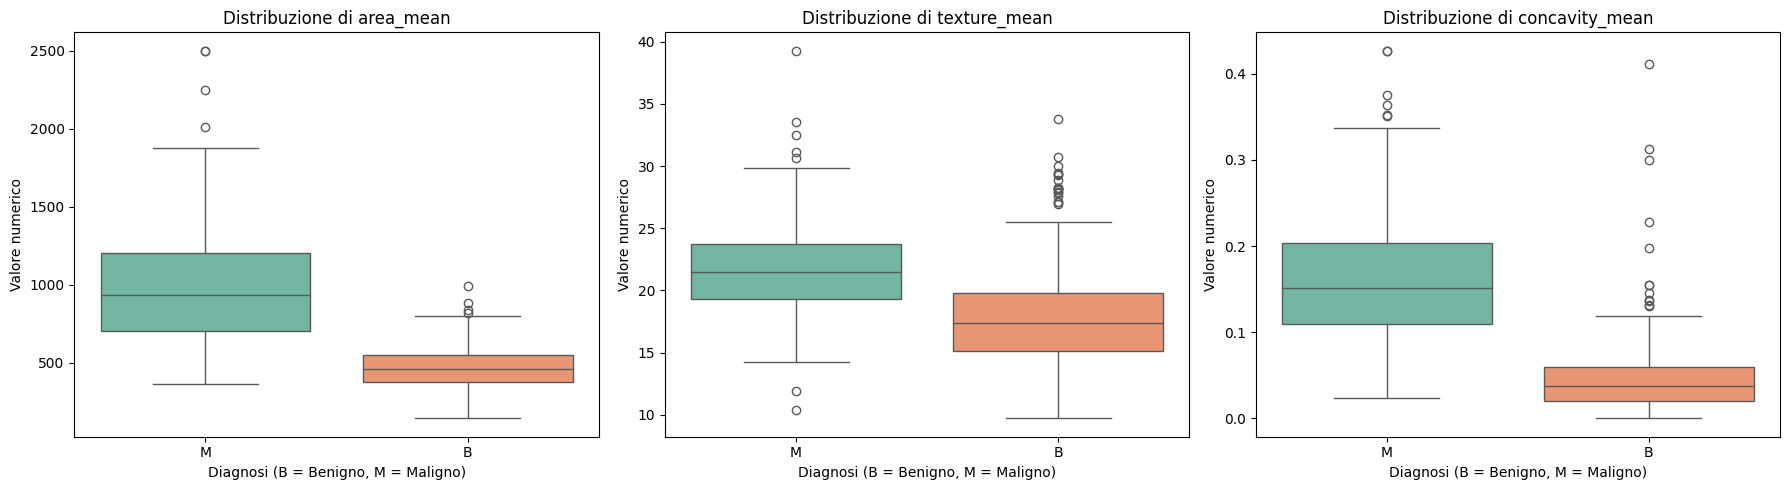

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rappresentanti = ['area_mean', 'texture_mean', 'concavity_mean']

for i, feature in enumerate(rappresentanti):
    sns.boxplot(ax=axes[i], x='diagnosis', y=feature, data=df, hue='diagnosis', palette='Set2', legend=False)
    axes[i].set_title(f'Distribuzione di {feature}')
    axes[i].set_xlabel('Diagnosi (B = Benigno, M = Maligno)')
    axes[i].set_ylabel('Valore numerico')

plt.tight_layout()
plt.show()

Dal grafico si evidenzia che per la media dell'area i Maligni sono più grandi, hanno valori che vanno da circa 750 a 1200 mentre i Benigni hanno dimensioni che vanno da circa 250 a 750. Stessa cosa la notiamo per la caratteristica della concavità. Analizzando ancora il grafico si vede che nei BoxPlot area_mean e concavity_mean si vede da subito una netta distinsione tra i Maligni e i Benigni, mentre texture_mean in parte si sovrappongono. La suddivisione netta ci fa pensare che possiamo usare un modello di regressione logistica. Altra cosa da notare e da non sottovalutare è che le scale di ogni cartteristica è diversa, dovremo effettuare uno scaling. Infine possiamo vedere anche che sono presenti degli outlier rappresentati dai cerchietti oltre i baffi del grafico.  

Eventuali correlazioni

Per evidenziare eventuali correlazioni tra le caratteristiche usiamo il metodo corr() di pandas. Prima selezioniamo di nuovo i nostri 3 rappresentanti delle famiglie per vedere come correlano tra loro

In [55]:

rappresentanti = ['area_mean', 'texture_mean', 'concavity_mean']

tabella_correlazione = df[rappresentanti].corr()

print("--- MATRICE DI CORRELAZIONE NUMERICA ---")
print(tabella_correlazione)

--- MATRICE DI CORRELAZIONE NUMERICA ---
                area_mean  texture_mean  concavity_mean
area_mean        1.000000      0.321086        0.685983
texture_mean     0.321086      1.000000        0.302418
concavity_mean   0.685983      0.302418        1.000000


Osserviamo la Matrice di Correlazione Numerica

Gli indici di correlazione di Pearson, che vanno da -1 a +1 ,estratti sui tre rappresentanti delle famiglie di caratteristiche, vediamo che tra area e concavità c'è una forte relazione, che al crescere dell'area cresce anche la concavità, ci avviciniamo molto al valore 1 mentre la relazione tra la texture ed entrambe le altre due caratteristiche è molto più bassa, questo ci fa capire che è indipendente dalle altre. 

# 5. Outlier detection / preprocessing

In questa sezione affrontare:
- valori anomali
- valori improbabili o critici
- eventuali strategie di pulizia
- tecniche di outlier detection
- motivazione delle scelte di preprocessing finale


Preparazione dei dati per i modelli.

Come primo passo trasformiamo il target Diagnosis che ha come  valori attuali 'M' e 'B' in numerico (1 e 0)".

In [56]:
mappa_diagnosi = {'M': 1, 'B': 0}
df['diagnosis'] = df['diagnosis'].replace(mappa_diagnosi).infer_objects(copy=False)
df['diagnosis'].head()

C:\Users\antonino.cardillo\AppData\Local\Temp\ipykernel_8236\1761074491.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diagnosis'] = df['diagnosis'].replace(mappa_diagnosi).infer_objects(copy=False)


0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

## Identifichiamo gli Outlier
Per identificare e isolare gli outlier useremo lo Z-Score Standard, che si basa sulla media e deviazione standard, sulle nostre feature per identificare quali righe superano la soglia critica di 3 deviazioni standard dalla media, questo valore normalmente viene considerato statisticamente un'anomalia estrema.



Escludiamo la colonna target diagnosis che non ci viene utile
nel calcolo dello Z-Score.
Il calcolo lo faremo sul'intero dataset e non solo su determinate caratteristiche.

In [57]:
feature_cols = [col for col in df.columns if col != 'diagnosis']

CAlcoliamo lo z-score

In [58]:
z_scores = np.abs(stats.zscore(df[feature_cols]))

Evidenziamo quale caratteristica ha il valore superiore o inferiore a 3 deviazioni standard e quindi quali pazienti.

In [59]:
righe_outlier = np.where(z_scores > 3)[0]

Potrebbe essere che una paziente abbia non una sola caratteristica che identificata come outlier ma più di una quindi per non avere più volte la stessa paziente andiamo a prenderla una sola volta usando unique

In [60]:
righe_outlier_uniche = np.unique(righe_outlier)



Stampiamo i risultati

In [61]:
print(f"Numero di pazienti totali nel dataset: {df.shape[0]}")
print(f"Numero di pazienti identificati come outlier : {len(righe_outlier_uniche)}")

Numero di pazienti totali nel dataset: 569
Numero di pazienti identificati come outlier : 74


Il valore degli outlier è molto elevato in relazione all'intero dataset quindi teniamo questi valori considerando anche l'importanza e l'impatto sulle diagnosi future sulla vita dei pazienti.

# 6. Implementazione di uno o più modelli

In questa sezione descrivere:
- i modelli scelti
- le motivazioni della scelta
- lo split train/test oppure altra strategia di validazione
- l'addestramento dei modelli
- eventuali confronti tra metodi diversi


Implementazione di uno o più modelli

In questa sezione andiamo ad addestrare e confrontare quattro differenti architetture di Machine Learning analizzate durante il corso, coprendo modelli lineari, geometrici, probabilistici e connessionisti:
* Logistic Regression (Modello Lineare):
 Scelta perché l'EDA ha mostrato una buona separabilità geometrica delle classi nei boxplot.
* Support Vector Machines - SVM (Modello Geometrico):
 Ottimo per massimizzare il margine di separazione tra Benigni e Maligni in spazi multidimensionali.
* Random Forest (Modello basato su Alberi):
 Scelto perché non risente della multicollinearità tra raggio/area/perimetro che sono per forza di cose correlati fortemente tra loro ed è **robusto in presenza di outlier**.
* Multi-Layer Perceptron - MLP (Rete Neurale Artificiale):
Scelta per catturare eventuali relazioni non lineari complesse tra le caratteristiche geometriche delle cellule.


Prima di addestrare i modelli, dividiamo il dataset in un **Train set (80%)** per l'apprendimento e un **Test Set (20%)**. Per evitare il Data Leakage, faremo il fit dello StandardScaler solo sui dati di Train, e poi useremo quei dati per fare il transform sia sul Train che sul Test.

Come prima cosa separiamo Caratteristiche (X) dal Target (y)

In [62]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

Effettuiamo lo split Train/Test (80% / 20%) con stratificazione

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Inizializziamo lo StandardScaler

In [64]:
scaler = StandardScaler()

Scaliamo le caratteristiche in modo differenziato per evitare il Data Leakage

In [65]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Verifichiamo

In [66]:
print("--- VERIFICA FINALE DELLE DIMENSIONI ---")
print(f"Pazienti nel Train Set (X_train_scaled): {X_train_scaled.shape[0]}")
print(f"Pazienti nel Test Set (X_test_scaled): {X_test_scaled.shape[0]}")
print(f"Numero di feature in input per ogni paziente: {X_train_scaled.shape[1]}")

--- VERIFICA FINALE DELLE DIMENSIONI ---
Pazienti nel Train Set (X_train_scaled): 455
Pazienti nel Test Set (X_test_scaled): 114
Numero di feature in input per ogni paziente: 30


Iniziamo ad utilizzare Logistic Regression

Importiamo le librerie del modello e le metriche

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

Inizializziamo il modello (usiamo random_state per la riproducibilità)

In [68]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)

Addestriamo il modello sui dati scalati del Train Set

In [69]:
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Facciamo le predizioni sui dati del Test Set e stampiamo il report di classificazione.

In [70]:
y_pred_lr = lr_model.predict(X_test_scaled)

print("--- PERFORMANCE LOGISTIC REGRESSION (TEST SET) ---")
print(classification_report(y_test, y_pred_lr))

--- PERFORMANCE LOGISTIC REGRESSION (TEST SET) ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Interpretiamo i coifficienti facendo un'estrazione e associandoli ai nomi delle colonne originali

In [71]:
pesi_features = pd.DataFrame({
    'Feature': X.columns,
    'Coefficiente (Peso)': lr_model.coef_[0]
})

Ordiniamo i pesi dal più influente al meno influente per la classe 1 (Maligno)

In [72]:
pesi_features = pesi_features.sort_values(by='Coefficiente (Peso)', ascending=False)

Stampiamo e confrontiamo sia le prime 5 che le ultime 5 con head() e tail()

In [73]:
print("--- PESI DELLE CARATTERISTICHE NELLA LOGISTIC REGRESSION ---")
print(pesi_features.head(5)) 
print("\n...")
print(pesi_features.tail(5))

--- PESI DELLE CARATTERISTICHE NELLA LOGISTIC REGRESSION ---
                Feature  Coefficiente (Peso)
21        texture_worst             1.434093
10            radius_se             1.233325
28       symmetry_worst             1.061264
7   concave points_mean             0.952813
26      concavity_worst             0.911406

...
                 Feature  Coefficiente (Peso)
18           symmetry_se            -0.330658
11            texture_se            -0.407611
5       compactness_mean            -0.439546
19  fractal_dimension_se            -0.593876
15        compactness_se            -0.906925


L'estrazione dei coefficienti della Logistic Regression ci fa notare che le caratteristiche prese in esame nell'EDA ritornano anche se non come media dei valori ma i valori peggiori. Infatti tra i più pesanti ritroviamo sia texture che concavity.

Notiamo anche che viene evidenziato il valore della diversità del raggio delle cellule (standard error) quindi la variabilità nello stesso tessuto, anche questo può essere considerato un biomarcatore tumorale maligno.


Passiamo al secondo modello per capire se si riesce a fare meglio, usiamo SVM. Questo modello cerca di determinare un iperpiano di separazione tra le caratteristiche, nel nostro caso in due classi. Utilizziamo un kernel lineare in quanto abbiamo già assodato che le due classi sono divisibili bene.  

Importiamo la libreria e inizializziamo il modello con il kernel lineare e il random_state impostato a 42

In [74]:
from sklearn.svm import SVC
svm_model = SVC(kernel='linear', random_state=42, probability=True)

Addestriamo il modello sui dati del Train Set scalati e effettuiamo la predizione sui dati del Test Set

In [75]:
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

Stampiamo il report di predizione di SVM

In [76]:
print("--- PERFORMANCE SUPPORT VECTOR MACHINE (TEST SET) ---")
print(classification_report(y_test, y_pred_svm))

--- PERFORMANCE SUPPORT VECTOR MACHINE (TEST SET) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



Entrambi i modelli si sono comportati in modo quasi identico sul piano dell'accuratezza globale (96%), ma la vera differenza emerge dall'analisi della Recall (sensibilità). Un valore di Recall più elevato è fondamentale in questo contesto perché ci permette di ridurre al minimo i **falsi negativi**, evitando così il rischio gravissimo di considerare sana una paziente che in realtà è affetta da un tumore maligno. 

Il prossimo modello che andremo ad addestrare per valutarne le performance è la **Random Forest**. A differenza dei primi due, questo non è un modello lineare: si tratta di un algoritmo basato su alberi di decisione, più robusto in presenza di outlier e capace di gestire la forte correlazione tra le caratteristiche geometriche senza subire alterazione nei risultati.

Importiamo la libreria del modello e inizializziamo impostando il valore di estimatore a 100 e random state a 42

In [77]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

Addestriamo il modello sui dati del Train Set scalati e effettuiamo la predizione del Test Set

In [78]:
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

Stampiamo il report di classificazione

In [79]:

print("--- PERFORMANCE RANDOM FOREST (TEST SET) ---")
print(classification_report(y_test, y_pred_rf))

--- PERFORMANCE RANDOM FOREST (TEST SET) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



Il fatto stesso che questo modello, come già avevamo accennato, non soffra delle correlazioni tra le caratteristiche grazie al suo modo di analizzare i dati (generando tanti alberi, nel nostro caso 100, dove ognuno elabora le caratteristiche separatamente), gli ha permesso di performare meglio. Ha infatti raggiunto un F1-score del 96% (contro il 95% degli altri due modelli), riuscendo inoltre a unire il meglio dei due approcci lineari: la Precision del 100% della SVM e la Recall del 93% della Logistic Regression.

Come ultimo modello che analizzeremo è il MLP, una rete neurale multi layer.

Come per tutti i modelli importiamo le librerie e inizializziamo creando un livello nascosto con 50 nuroni, usiamo l'attivazione 'relu' e max_iter=1000 per farlo convergere

In [80]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(hidden_layer_sizes=(50,), activation='relu', random_state=42, max_iter=1000)

Addestriamo la rete neurale sui dati scalati ed effettuiamo la predizione dul Test Set

In [81]:
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)

Stampiamo il report di classificazione

In [82]:
print("--- PERFORMANCE MULTI-LAYER PERCEPTRON (TEST SET) ---")
print(classification_report(y_test, y_pred_mlp))

--- PERFORMANCE MULTI-LAYER PERCEPTRON (TEST SET) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



Notiamo subito che la Precision è confermata al 100%, mentre la Recall è scesa al 90% e di conseguenza anche l'F1-score è calato al 95%. Questo non signfica che il Multi-Layer Perceptron (MLP) sia un modello scadente, ma conferma che le Reti Neurali Artificiali hanno bisogno di enormi volumi di dati per esprimere il loro potenziale. Avendo a disposizione un dataset di dimensioni ridotte (455 pazienti nel Train Set), la rete non è riuscita a superare la Random Forest, che si conferma l'algoritmo migliore per questo tipo di dati.

# 7. Valutazione e confronto dei risultati

In questa sezione inserire:
- metriche di valutazione
- grafici di confronto
- eventuale confusion matrix o altri strumenti diagnostici
- confronto tra modelli o approcci
- interpretazione critica dei risultati


# 8. Conclusioni finali

In questa sezione riassumere:
- il problema affrontato
- il metodo seguito
- i risultati principali
- le conclusioni più importanti
- eventuali limiti del lavoro svolto
